In [1]:
# data tools and plotting

from feature_eng import TSFE
import logging
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)
#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay

import mlflow
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000);
#=========================
#=====================
#=========mlflow setting==========


#mlflow.set_tracking_uri(
#    "http://127.0.0.1:5000"
#)


#mlflow.set_experiment('isCnan_mhd')
#=============== feature engineering and define the needed features

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 

       'level_rt_ratio', 'rt_position', 'baseline_slope', 'level_area_ratio'
       #'is_ht_zero_and_C_Nan','is_normal_std', 
       # #'is_bad_std', 'is_protential_flagged_air'
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' ,#'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1]},

    

    'roll_std':{'cols': ['CH4_w', 'CH4_end_time','CH4_ht','CH4_area'], 'period':['40min','2h']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area'], 'period': ['40min','2h']},

    'diff_cross':{'cols':[['CH4_end_time', 'CH4_start_time'],
                          # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                           #['CH4_end_level', 'CH4_start_level'],
                            #['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                           #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                           ]}, 

    #'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
     #              ]},
     'roll_median':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area'], 'period':['40min','2h']},
     'roll_mad':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area'], 'period':['40min','2h'] },
     'roll_median_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area'], 'period':['40min','2h']},

    'multi':{'cols':[['CH4_w', 'CH4_ht'],]},

    'ratio':{'cols':[   
                        ['CH4_area','CH4_w_CH4_ht_multi'], ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                       # ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                       # ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                      
                        ['CH4_start_level', 'CH4_end_level'],
                  
                        ['CH4_w_roll_std_40min', 'CH4_w_roll_mean_40min'], ['CH4_ht_roll_std_40min', 'CH4_ht_roll_mean_40min'],['CH4_area_roll_std_40min', 'CH4_area_roll_mean_40min'],
                        ['CH4_w_roll_std_2h', 'CH4_w_roll_mean_2h'], ['CH4_ht_roll_std_2h', 'CH4_ht_roll_mean_2h'],['CH4_area_roll_std_2h', 'CH4_area_roll_mean_2h'],
                        #['CH4_w_roll_std_6h', 'CH4_w_roll_mean_6h'], ['CH4_ht_roll_std_6h', 'CH4_ht_roll_mean_6h'],['CH4_area_roll_std_6h', 'CH4_area_roll_mean_6h'],
                        #['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h']
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        #['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        #['CH4_rt', 'last_std_rt'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_end_time','CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_2h', 'CH4_w_roll_std_2h', '2h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7h','7D']},


}

In [2]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.columns.tolist()

target_cols = ['ht', 'area', 'rt', 'start_level']

for col in target_cols:
    col = f'CH4_{col}'

    for t_type in ['std', 'air']:
        type_median = df.loc[df['type'] == t_type, col ].median()

        only_series = df[col].where(df['type']==t_type)
        df[f'last_{t_type}_{col}'] = only_series.ffill().shift(1).fillna(type_median)


df['level_rt_ratio'] = (df['CH4_end_time'] -df['CH4_start_time'])/df['CH4_rt']
df['rt_position'] = (df['CH4_rt'] - df['CH4_start_time']) / df['CH4_w']
df['baseline_slope'] =(df['CH4_end_level'] -df['CH4_start_level'])/df['CH4_w']
df['level_area_ratio'] = np.maximum(df['CH4_end_level'],df['CH4_start_level'] )/(df['CH4_area'])

#   Corr - isC_nan


#=====================ml PART

In [3]:
target ='label_c_nan'

In [4]:
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'is_air', 'is_std', 'level_rt_ratio', 'rt_position', 'baseline_slope',
       'level_area_ratio'],
      dtype='object')


,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,level_rt_ratio,rt_position,baseline_slope,level_area_ratio
datetime,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,NaN,NaN,NaN,NaN
1994-02-16 14:49:00,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,NaN,NaN,NaN,NaN
1994-02-16 15:09:00,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0,0.304189,3.000000,-13.076923,0.020270
1994-02-16 15:29:00,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0,0.451477,1.255474,0.000000,0.093809
1994-02-16 18:00:00,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,NaN,NaN,NaN,NaN


In [5]:
import shap
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()
print(X_train_final.columns)
#X_train_final = X_train_final[feature_ml]


Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'is_air', 'is_std', 'level_rt_ratio', 'rt_position', 'baseline_slope',
       'level_area_ratio', 'CH4_area_diff_1', 'CH4_ht_diff_1', 'CH4_w_diff_1',
       'CH4_area_lag_1', 'CH4_rt_lag_1', 'CH4_ht_lag_1', 'pflow_lag_1',
       'CH4_w_lag_1', 'CH4_w_roll_std_40min', 'CH4_w_roll_std_2h',
       'CH4_end_time_roll_std_40min', 'CH4_end_time_roll_std_2h',
       'CH4_ht_roll_std_40min', 'CH4_ht_roll_std_2h',
       'CH4_area_roll_std_40min', 'CH4_area_roll_std_2h',
       'CH4_rt_roll_mean_40min', 'CH4_rt_residual_40min',
       'CH4_rt_roll_mean_2h', 'CH4_rt_residual_2h', 'CH4_w_roll_mean_40min',
       'CH4_w_residual_40min', 'CH4_w_roll_mean_2h', 'CH4_w_residual_2h',
       'CH4_ht_roll_mean_40min', 'CH4_ht_residual_40min',
       'CH4_ht_roll_mean_2h', 'CH4_ht_residual_2h', 'CH4_area_roll_mean_40min',
       'CH4_area_residual

In [6]:
import shap
from pulearn import ElkanotoPuClassifier
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()
print(X_train_final.columns)
X_test_final = tsfe.transform(X_test)
y_test_final = y_test.copy()
#=================
base_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42
)

pu_estimator = ElkanotoPuClassifier(
    estimator=base_rf,
    hold_out_ratio=0.2
)

pu_estimator.fit(X_train_final, y_train_final)



Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'is_air', 'is_std', 'level_rt_ratio', 'rt_position', 'baseline_slope',
       'level_area_ratio', 'CH4_area_diff_1', 'CH4_ht_diff_1', 'CH4_w_diff_1',
       'CH4_area_lag_1', 'CH4_rt_lag_1', 'CH4_ht_lag_1', 'pflow_lag_1',
       'CH4_w_lag_1', 'CH4_w_roll_std_40min', 'CH4_w_roll_std_2h',
       'CH4_end_time_roll_std_40min', 'CH4_end_time_roll_std_2h',
       'CH4_ht_roll_std_40min', 'CH4_ht_roll_std_2h',
       'CH4_area_roll_std_40min', 'CH4_area_roll_std_2h',
       'CH4_rt_roll_mean_40min', 'CH4_rt_residual_40min',
       'CH4_rt_roll_mean_2h', 'CH4_rt_residual_2h', 'CH4_w_roll_mean_40min',
       'CH4_w_residual_40min', 'CH4_w_roll_mean_2h', 'CH4_w_residual_2h',
       'CH4_ht_roll_mean_40min', 'CH4_ht_residual_40min',
       'CH4_ht_roll_mean_2h', 'CH4_ht_residual_2h', 'CH4_area_roll_mean_40min',
       'CH4_area_residual

,estimator,RandomForestC...ndom_state=42)
,hold_out_ratio,0.2
,random_state,None
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [7]:
best_threshold = 0.85
y_prob = pu_estimator.predict_proba(X_test_final)[:,1]

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


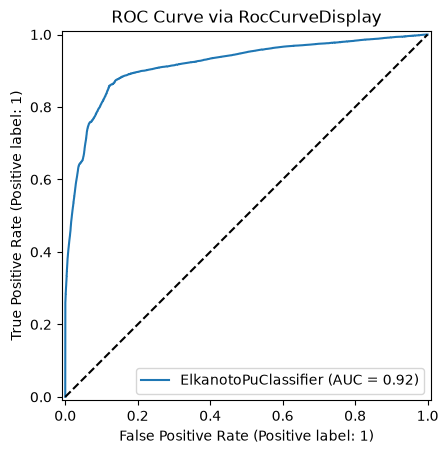

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


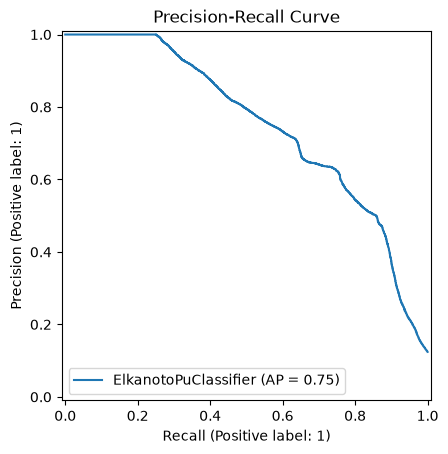

In [8]:

#=========== plotting
#======== ROC
RocCurveDisplay.from_estimator(pu_estimator, X_test_final, y_test_final)

plt.title("ROC Curve via RocCurveDisplay")
plt.plot([0, 1], [0,1], 'k--') 
plt.savefig("image/ROC_Curve.png")
#mlflow.log_artifact("image/ROC_Curve.png")
plt.show()    
plt.close()
# ======= PRC 
PrecisionRecallDisplay.from_estimator(pu_estimator, X_test_final, y_test_final)

plt.title("Precision-Recall Curve")
plt.savefig("image/PRC_Curve.png")
#mlflow.log_artifact("image/PRC_Curve.png")
plt.show()    
plt.close()

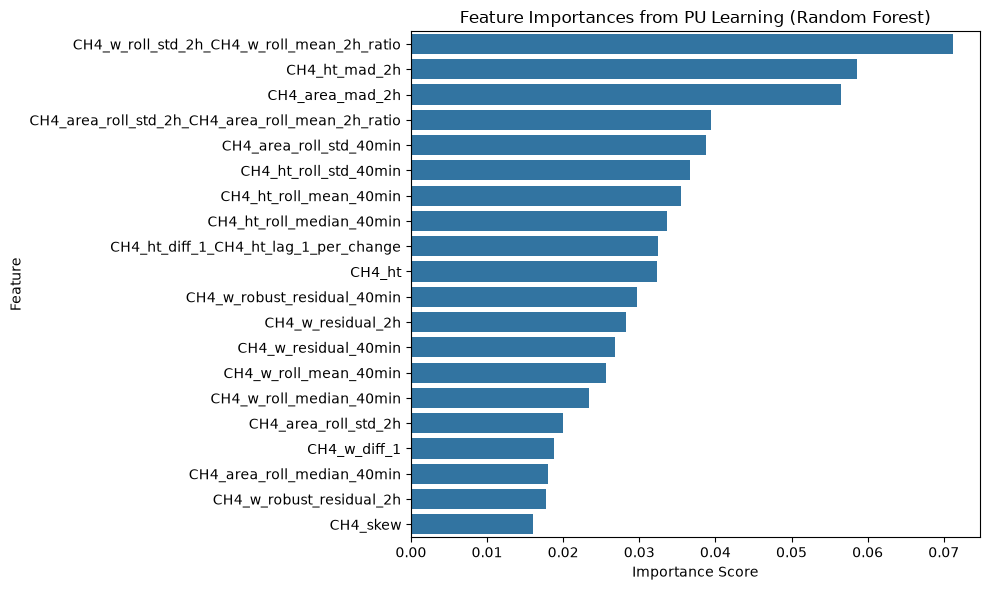

In [9]:
base_rf = pu_estimator.estimator

importances = base_rf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20))
plt.title('Feature Importances from PU Learning (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [31]:
feature_imp_df['Feature'].tolist()

['CH4_ht_roll_std_40min',
 'CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio',
 'CH4_ht_roll_median_40min',
 'CH4_ht_mad_2h',
 'CH4_area_roll_std_40min',
 'CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio',
 'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
 'CH4_area_mad_2h',
 'CH4_ht_roll_mean_40min',
 'CH4_ht',
 'CH4_w_residual_40min',
 'CH4_w_robust_residual_40min',
 'CH4_w_roll_mean_40min',
 'CH4_w_residual_2h',
 'CH4_w_CH4_ht_multi',
 'CH4_w_diff_1',
 'CH4_skew',
 'CH4_w_robust_residual_2h',
 'CH4_area_roll_median_40min',
 'CH4_start_time',
 'CH4_area_roll_mean_2h',
 'CH4_area_roll_std_2h',
 'CH4_ht_roll_mean_2h',
 'CH4_w_residual_6h',
 'CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio',
 'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio',
 'CH4_area',
 'CH4_end_time',
 'CH4_w_roll_std_2h',
 'CH4_w_robust_residual_6h',
 'CH4_area_roll_mean_40min',
 'CH4_w',
 'CH4_w_roll_median_40min',
 'CH4_end_time_CH4_start_time_diff_cross',
 'CH4_rt_roll_mean_40min',
 'CH4_ht_roll_std_2h',
 'CH4_area_roll_median

In [9]:
best_threshold = 0.85
y_prob = pu_estimator.predict_proba(X_test_final)[:,1]
y_prob = np.clip(y_prob, 0.0, 1.0)
y_proba_best = (y_prob >= best_threshold).astype(int)

analysis_df = pd.DataFrame({
    'original_index': X_test_final.index,
    'true_label': y_test.values,
    'predicted_label': y_proba_best,
    'predicted_prob': y_prob
}, index=X_test_final.index)

errors_df = analysis_df[analysis_df['true_label'] != analysis_df['predicted_label']].copy()

def error_type(row):
    if row['true_label'] == 1 and row['predicted_label'] == 0:
        return 'False Negative, actual 1; predicted 0, confirmed flag, but model missed'
    elif row['true_label'] == 0 and row['predicted_label'] == 1:
        return 'Potential Hidden Flag( actual 0; predicted 1; Unlabled, but high prob)'

errors_df['error_type'] = errors_df.apply(error_type, axis=1)

errors_df['severity'] = (errors_df['predicted_prob'] - best_threshold).abs()

errors_df = errors_df.join(X_test_final)

errors_df = errors_df.sort_values(by='severity', ascending=False)

print('==== ERROR SUMMARY===')
print(f'error per: {len(errors_df)/len(X_test_final):.2%}')

#errors_df.to_csv('error_analysis_with_index.csv', index=True)#=========
fp_flag_df = errors_df[errors_df['error_type'].str.contains('Potential Hidden Flag')].copy()

fp_flag_df.head(20)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


==== ERROR SUMMARY===
error per: 7.94%


,original_index,true_label,predicted_label,predicted_prob,error_type,severity,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_CH4_ht,last_air_CH4_ht,last_std_CH4_area,last_air_CH4_area,last_std_CH4_rt,last_air_CH4_rt,last_std_CH4_start_level,last_air_CH4_start_level,level_rt_ratio,rt_position,baseline_slope,level_area_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_w_diff_1,CH4_area_lag_1,CH4_rt_lag_1,CH4_ht_lag_1,pflow_lag_1,CH4_w_lag_1,CH4_w_roll_std_40min,CH4_w_roll_std_2h,CH4_w_roll_std_6h,CH4_w_roll_std_24h,CH4_w_roll_std_2D,CH4_end_time_roll_std_40min,CH4_end_time_roll_std_2h,CH4_end_time_roll_std_6h,CH4_end_time_roll_std_24h,CH4_end_time_roll_std_2D,CH4_ht_roll_std_40min,CH4_ht_roll_std_2h,CH4_ht_roll_std_6h,CH4_ht_roll_std_24h,CH4_ht_roll_std_2D,CH4_area_roll_std_40min,CH4_area_roll_std_2h,CH4_area_roll_std_6h,CH4_area_roll_std_24h,CH4_area_roll_std_2D,CH4_rt_roll_mean_40min,CH4_rt_residual_40min,CH4_rt_roll_mean_2h,CH4_rt_residual_2h,CH4_rt_roll_mean_6h,CH4_rt_residual_6h,CH4_rt_roll_mean_24h,CH4_rt_residual_24h,CH4_rt_roll_mean_2D,CH4_rt_residual_2D,CH4_w_roll_mean_40min,CH4_w_residual_40min,CH4_w_roll_mean_2h,CH4_w_residual_2h,CH4_w_roll_mean_6h,CH4_w_residual_6h,CH4_w_roll_mean_24h,CH4_w_residual_24h,CH4_w_roll_mean_2D,CH4_w_residual_2D,CH4_ht_roll_mean_40min,CH4_ht_residual_40min,CH4_ht_roll_mean_2h,CH4_ht_residual_2h,CH4_ht_roll_mean_6h,CH4_ht_residual_6h,CH4_ht_roll_mean_24h,CH4_ht_residual_24h,CH4_ht_roll_mean_2D,CH4_ht_residual_2D,CH4_area_roll_mean_40min,CH4_area_residual_40min,CH4_area_roll_mean_2h,CH4_area_residual_2h,CH4_area_roll_mean_6h,CH4_area_residual_6h,CH4_area_roll_mean_24h,CH4_area_residual_24h,CH4_area_roll_mean_2D,CH4_area_residual_2D,CH4_end_time_CH4_start_time_diff_cross,last_std_CH4_ht_last_air_CH4_ht_diff_cross,CH4_ht_last_std_CH4_ht_diff_cross,CH4_ht_last_air_CH4_ht_diff_cross,last_std_CH4_ht_log,last_air_CH4_ht_log,CH4_w_CH4_ht_multi,CH4_end_time_CH4_start_time_diff_cross_last_std_CH4_ht_log_multi,CH4_end_time_CH4_start_time_diff_cross_last_air_CH4_ht_log_multi,CH4_area_CH4_w_CH4_ht_multi_ratio,CH4_ht_CH4_area_ratio,CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio,CH4_ht_last_air_CH4_ht_ratio,last_std_CH4_ht_last_air_CH4_ht_ratio,CH4_start_level_CH4_end_level_ratio,CH4_area_last_std_CH4_area_ratio,CH4_start_level_last_std_CH4_start_level_ratio,CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio,CH4_ht_roll_std_40min_CH4_ht_roll_mean_40min_ratio,CH4_area_roll_std_40min_CH4_area_roll_mean_40min_ratio,CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio,CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio,CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio,CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio,CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio,CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio,CH4_ht_diff_1_CH4_ht_lag_1_per_change,last_std_CH4_ht_last_air_CH4_ht_per_change,CH4_w_relative_per_2h,CH4_w_relative_per_7h,CH4_end_time_relative_per_2h,CH4_end_time_relative_per_7h,CH4_ht_relative_per_2h,CH4_ht_relative_per_7h,CH4_w_2h_zcore_res_gen,CH4_w_per_rank_7h,CH4_w_per_rank_7D,CH4_w_per_rank_30D,CH4_skew_per_rank_7h,CH4_skew_per_rank_7D,CH4_skew_per_rank_30D,CH4_ht_per_rank_7h,CH4_ht_per_rank_7D,CH4_ht_per_rank_30D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-07-06 12:05:00,2025-07-06 12:05:00,0,1,1.0,Potential Hidden Flag( actual 0; predicted 1; ...,0.15,800.200012,40.0,96.000000,7.79,165991.0,1439762.0,1.07,82.800003,134.800003,28455.0,28635.0,1,0,163544.0,165960.0,1443623.0,1442543.0,96.000000,96.000000,28371.0,28199.0,0.541667,1.694480,23.106546,0.019889,-3861.0,2447.0,-0.13,1443623.0,96.000000,163544.0,808.799988,7.92,0.084853,0.050761,0.030705,0.021510,0.018146,0.141421,0.163299,0.155509,0.125469,0.111545,1708.369995,1284.904297,946.466309,854.504333,955.984436,763.675354,5864.546875,6656.481934,6186.773926,7806.000977,96.000000,

-----------------------------------